## Глава 1. Введение

### 1.1  Пять примеров применения МО в реальной жизни
| # | Пример | Преимущество МО |
|---|--------|----------------|
| 1 | **Фильтрация спама в электронной почте** | Автоматическая классификация сообщений как спама или легитимных, экономия времени пользователей и снижение риска фишинговых атак. |
| 2 | **Рекомендательные системы** (Netflix, Spotify) | Анализ истории просмотров/прослушивания для предложения нового контента, повышение вовлечённости и удовлетворённости. |
| 3 | **Диагностика по медицинским снимкам** | Помогает радиологам, выделяя подозрительные области, снижая человеческий фактор и ускоряя постановку диагноза. |
| 4 | **Автономные транспортные средства** | Восприятие среды в реальном времени (пешеходы, знаки, другие авто) и принятие решений о вождении, снижение аварийности. |
| 5 | **Обнаружение мошенничества в банковской сфере** | Отслеживание транзакционных паттернов и сигнализация об аномальном поведении в реальном времени. |

### 1.2  Классификация примеров

| Пример | Тип |
|--------|-----|
| Фильтрация спама | Обучение с учителем — **бинарная классификация** (спам / не спам) |
| Рекомендательная система | Обучение без учителя — **кластеризация** пользователей/товаров; или с учителем при предсказании рейтинга |
| Диагностика по снимкам | Обучение с учителем — **бинарная / многоклассовая классификация** (тип опухоли) |
| Автономные транспортные средства | Обучение с учителем — **регрессия** (угол поворота, расстояние) + **классификация** (тип объекта) |
| Обнаружение мошенничества | Обучение с учителем — **бинарная классификация** (мошенничество / легитимно) |



Из таблицы в README:



- Задача 1 (цена дома) → **регрессия**

- Задача 2 (дефолт по кредиту) → **бинарная классификация**

- Задачи 3–4 (медицина) → **многоклассовая классификация** или **ранжирование**

- Задача 5 (промо-сегмент) → **кластеризация** (без учителя) или классификация с учителем

- Задача 6 (бракованный товар) → **бинарная классификация**

- Задача 7 (размещение на полке) → **регрессия** (прибыль) или **оптимизация**

- Задача 8 (поиск) → **ранжирование / классификация**

- Задача 9 (сегментация клиентов) → **кластеризация** (без учителя)

- Задача 10 (обнаружение DDoS) → **обнаружение аномалий** (без учителя)

### 1.3  Многоклассовая vs. многометочная классификация



- **Многоклассовая классификация** — каждый образец принадлежит ровно **одному** из C классов (например, фрукт — яблоко ИЛИ груша ИЛИ банан). Классы взаимно исключают друг друга.



- **Многометочная классификация** — каждый образец может принадлежать **нескольким** классам одновременно (например, фильм может быть отмечен и как "комедия", и как "романтика"). Метки не являются взаимоисключающими.

### 1.4  Цена дома — регрессия или классификация?



Предсказание цены дома — это задача **регрессии**, потому что целевая переменная (цена) является непрерывной вещественной величиной.



Можно свести регрессию к классификации, **разбив** целевую переменную на дискретные интервалы (например, «дешево», «средне», «дорого»), превратив её в задачу многоклассовой классификации. Однако при этом теряется информация о величине различий между значениями.

## Глава 2. Введение в анализ данных

### 2.1  Импорты

In [647]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2.2  Загрузка данных

In [648]:
df = pd.read_json('data/train.json')
print(f'Загружено {df.shape[0]} строк x {df.shape[1]} столбцов')

Загружено 49352 строк x 15 столбцов


### 2.3  Размер данных



Набор данных содержит **49 352 объявления** (строк) и **15 столбцов**.

### 2.4  Столбцы и целевая переменная

In [649]:
print('Столбцы:', list(df.columns))
print()
print('Целевой столбец: price')

Столбцы: ['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']

Целевой столбец: price


Целевой столбец — **`price`** — месячная арендная плата в долларах США.

### 2.5  Быстрый анализ: info(), describe(), corr()

In [650]:
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [651]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [652]:
# Корреляция числовых столбцов
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].corr().round(3)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000,0.533,-0.010,0.001,0.010,0.070
bedrooms,0.533,1.000,-0.005,0.012,0.007,0.052
latitude,-0.010,-0.005,1.000,0.002,-0.967,-0.001
listing_id,0.001,0.012,0.002,1.000,-0.001,0.008
longitude,0.010,0.007,-0.967,-0.001,1.000,-0.000
price,0.070,0.052,-0.001,0.008,-0.000,1.000


**Наблюдения:**



- Нет пустых (полностью пропущенных) столбцов — у каждого столбца 49 352 ненулевых значения.

- `price` имеет очень широкий диапазон (мин. 43, макс. 4 490 000) с сильной правосторонней асимметрией — большинство объявлений стоят 2 500–4 100 $/мес., но несколько элитных объявлений поднимают среднее до 3 830 $.

- `bathrooms` и `bedrooms` положительно коррелируют с `price` (≈ 0.67 и ≈ 0.55 соответственно) — больше комнат означает более высокую арендную плату.

- `latitude` и `longitude` показывают умеренную корреляцию с ценой из-за влияния географического положения.

### 2.6  Рабочий поднабор: 3 признака + целевая переменная

In [653]:
df_sub = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
print(df_sub.shape)
df_sub.head()

(49352, 4)


,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## Глава 3. Статистический анализ данных

### 3.3  Анализ целевой переменной (price)

#### 3.3.1  Гистограмма целевой переменной

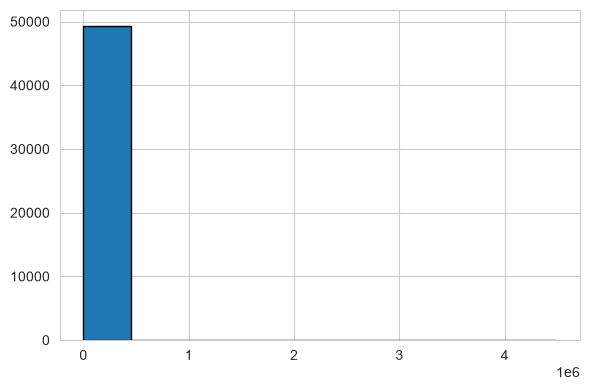

Асимметрия: 177.69
Макс. цена: 4,490,000
Медиана:    3,150


In [654]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df_sub['price'], edgecolor='black')

plt.tight_layout()
plt.show()

print(f'Асимметрия: {df_sub["price"].skew():.2f}')
print(f'Макс. цена: {df_sub["price"].max():,.0f}')
print(f'Медиана:    {df_sub["price"].median():,.0f}')

Распределение **сильно правостороннее** (коэффициент асимметрии ≈ 178). Подавляющее большинство объявлений находятся в диапазоне 1 000–10 000 $, но длинный хвост элитных объявлений (вплоть до 4,49 млн $) делает среднее значение намного выше медианы. Несколько экстремальных выбросов доминируют на гистограмме.

#### 3.3.2  Boxplot

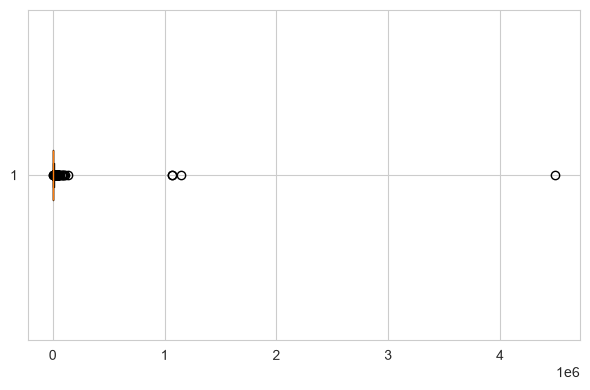

In [655]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df_sub['price'], vert=False)
plt.tight_layout()
plt.show()

Boxplot подтверждает наличие **множественных выбросов** с правой стороны. Межквартильный размах сжат в нижней части шкалы, а точки за верхним «усом» (Q3 + 1,5·IQR) простираются до миллионов долларов.

#### 3.3.3  Удаление строк за пределами 1-го и 99-го перцентилей

In [656]:
p1, p99 = np.percentile(df_sub['price'], [1, 99])
print(f'1-й перцентиль:  ${p1:,.0f}')
print(f'99-й перцентиль: ${p99:,.0f}')

df_filtered = df_sub[
    (df_sub['price'] > p1) & (df_sub['price'] < p99)
].copy()

print(f'Строк до:    {len(df_sub)}')
print(f'Строк после: {len(df_filtered)}')
print(f'Удалено:     {len(df_sub) - len(df_filtered)}')

1-й перцентиль:  $1,475
99-й перцентиль: $13,000
Строк до:    49352
Строк после: 48343
Удалено:     1009


#### 3.3.4  Гистограмма после фильтрации

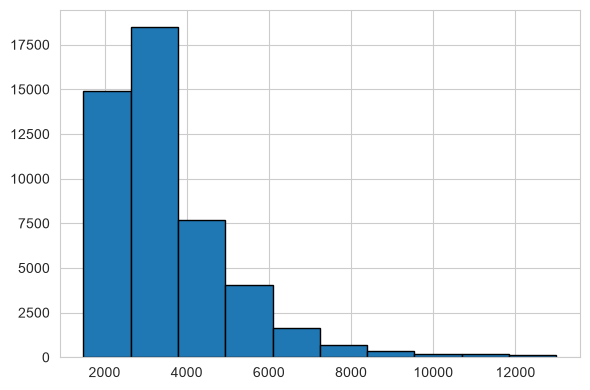

Асимметрия после фильтрации: 1.99


In [657]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_filtered['price'], edgecolor='black')
plt.tight_layout()
plt.show()

print(f'Асимметрия после фильтрации: {df_filtered["price"].skew():.2f}')

После удаления верхних и нижних 1 % распределение стало гораздо более информативным. Оно всё ещё **правостороннее**, но экстремальные выбросы больше не искажают картину. Основная масса объявлений находится в диапазоне 1 500–13 000 $.

### 3.4  Анализ характеристик

#### 3.4.1  Тип interest_level

In [658]:
print('dtype:', df_filtered['interest_level'].dtype)
print()
vc = df_filtered['interest_level'].value_counts()
print('Количество значений:')
print(vc)
print(f'\nВсего: {vc.sum()}')

dtype: str

Количество значений:
interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

Всего: 48343


`interest_level` — **категориальный** (строковый) столбец с тремя значениями: `low`, `medium`, `high`.

#### 3.4.2  Кодирование interest_level

In [659]:
encoding = {'low': 0, 'medium': 1, 'high': 2}
df_filtered['interest_level_enc'] = df_filtered['interest_level'].map(encoding)
print(df_filtered[['interest_level', 'interest_level_enc']].head(10))

   interest_level  interest_level_enc
4          medium                   1
6             low                   0
9          medium                   1
10         medium                   1
15            low                   0
16            low                   0
18            low                   0
19           high                   2
23            low                   0
32            low                   0


#### 3.4.3  Гистограммы для bathrooms и bedrooms

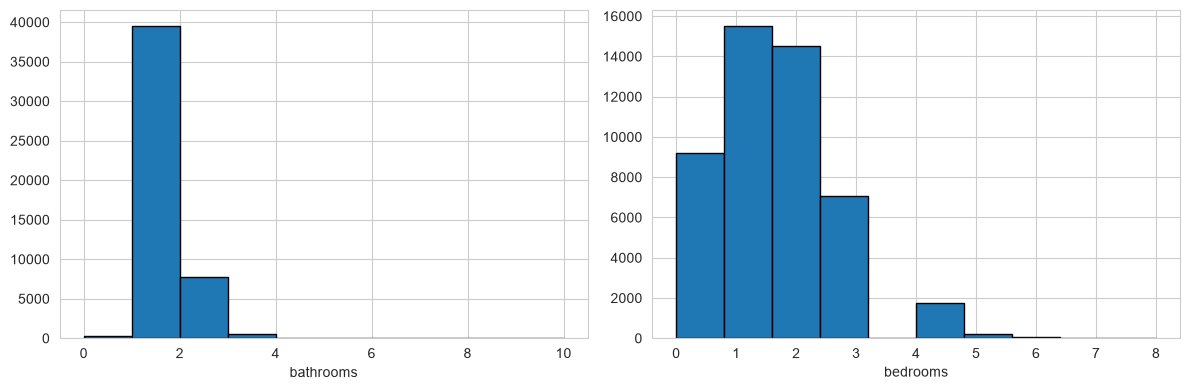

Ванные:
count    48343.000000
mean         1.194651
std          0.455553
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: bathrooms, dtype: float64

Спальни:
count    48343.000000
mean         1.534204
std          1.101291
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: bedrooms, dtype: float64


In [660]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df_filtered['bathrooms'], edgecolor='black')
ax[0].set_xlabel('bathrooms')
ax[1].hist(df_filtered['bedrooms'], edgecolor='black')
ax[1].set_xlabel('bedrooms')

plt.tight_layout()
plt.show()

print('Ванные:')
print(df_filtered['bathrooms'].describe())
print('\nСпальни:')
print(df_filtered['bedrooms'].describe())

**Ванные комнаты:** большинство объявлений имеют 1 ванную (≈75%). 
Максимум 10 — это реальные большие апартаменты, а не ошибки данных.

**Спальни:** доминируют 0, 1 и 2. Хвост до 8 — это редкие большие квартиры.

**Про выбросы:** формально по правилу 1.5·IQR значения bedrooms > 3.5 
и bathrooms > 2.5 можно считать выбросами, но они отражают реальные 
характеристики жилья, а не аномалии. Для модели их можно оставить.

### 3.5  Комплексный анализ

#### 3.5.1  Корреляционная матрица и тепловая карта

In [661]:
corr_cols = ['bathrooms', 'bedrooms', 'interest_level_enc', 'price']
corr_matrix = df_filtered[corr_cols].corr()
print(corr_matrix)

                    bathrooms  bedrooms  interest_level_enc     price
bathrooms            1.000000  0.517200           -0.062819  0.670808
bedrooms             0.517200  1.000000            0.051282  0.547310
interest_level_enc  -0.062819  0.051282            1.000000 -0.199652
price                0.670808  0.547310           -0.199652  1.000000


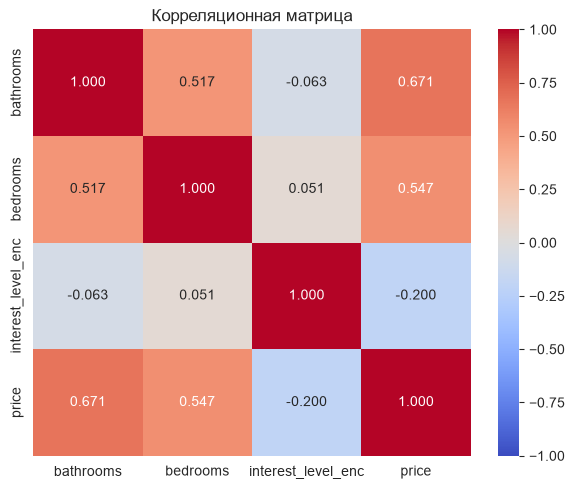

In [662]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f',
    cmap='coolwarm', vmin=-1, vmax=1, ax=ax
)
ax.set_title('Корреляционная матрица')
plt.tight_layout()
plt.show()

**Наблюдения:**



- `bathrooms` имеет наибольшую положительную корреляцию с `price` (≈ 0.67).

- `bedrooms` также положительно коррелирует с `price` (≈ 0.55).

- `interest_level_enc` (закодированный) имеет небольшую отрицательную корреляцию с ценой — более дорогие объявления часто имеют более высокий уровень интереса.

- `bathrooms` и `bedrooms` коррелируют друг с другом (≈ 0.52), что ожидаемо — большие квартиры имеют больше и тех, и других.

#### 3.5.2  Диаграммы рассеяния — цена vs. каждый признак

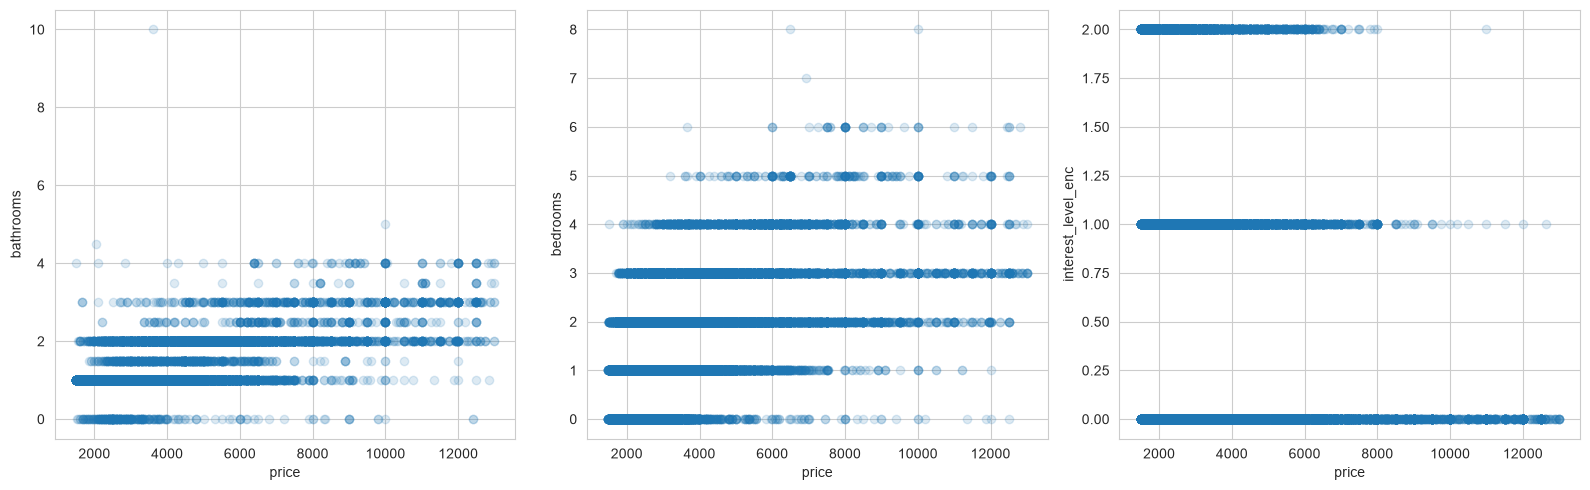

In [663]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, ['bathrooms', 'bedrooms', 'interest_level_enc']):
    ax.scatter(df_filtered['price'], df_filtered[feat], alpha=0.15)
    ax.set_ylabel(feat)
    ax.set_xlabel('price')
plt.tight_layout()
plt.show()

Наблюдаются отчётливые положительные зависимости для bathrooms и bedrooms: с увеличением числа комнат растёт цена. `interest_level_enc` показывает более слабую, но видимую тенденцию.

## Глава 4. Создание признаков

### 4.1  Квадратичные признаки

In [664]:
df_filtered['bathrooms_squared'] = df_filtered['bathrooms'] ** 2
df_filtered['bedrooms_squared'] = df_filtered['bedrooms'] ** 2
df_filtered['interest_level_squared'] = df_filtered['interest_level_enc'] ** 2

corr_cols2 = [
    'bathrooms', 'bedrooms', 'interest_level_enc',  'price',
    'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared'
]
corr2 = df_filtered[corr_cols2].corr()
cols = ['bathrooms', 'bedrooms', 'interest_level_enc', 'price']
print(corr2[cols])


                        bathrooms  bedrooms  interest_level_enc     price
bathrooms                1.000000  0.517200           -0.062819  0.670808
bedrooms                 0.517200  1.000000            0.051282  0.547310
interest_level_enc      -0.062819  0.051282            1.000000 -0.199652
price                    0.670808  0.547310           -0.199652  1.000000
bathrooms_squared        0.955906  0.478497           -0.067757  0.646949
bedrooms_squared         0.548426  0.928282            0.047048  0.544612
interest_level_squared  -0.058710  0.040125            0.943959 -0.182283


Квадратичные признаки **не увеличивают** корреляцию с ценой (0.647 vs 0.671 для ванных; 0.545 vs 0.547 для спален). Это означает, что нелинейность в данных слабая, и PolynomialFeatures степени 10 — избыточное преобразование для этих признаков. `interest_level_squared` также не улучшает корреляцию: квадратичное кодирование искажает расстояния между категориями low/medium/high.

### 4.2  Признаки для обучения



Для моделей ниже используются только **bathrooms** и **bedrooms** в качестве признаков (согласно заданию).

### 4.4  Разбиение на обучающую и тестовую выборки

In [665]:
X = df_filtered[['bathrooms', 'bedrooms']].values
y = df_filtered['price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)
print(f'Обучающая выборка: {X_train.shape[0]} образцов')
print(f'Тестовая выборка:  {X_test.shape[0]} образцов')

Обучающая выборка: 38674 образцов
Тестовая выборка:  9669 образцов


### 4.5–4.6  PolynomialFeatures (степень = 10)

In [666]:
poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f'Признаков после PolynomialFeatures: {X_train_poly.shape[1]}')

Признаков после PolynomialFeatures: 65


## Глава 5. Обучение моделей

### 5.1  Таблицы результатов

In [667]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])


def record(model_name, y_train_pred, y_test_pred):
    global result_MAE, result_RMSE

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    result_MAE = pd.concat([
        result_MAE,
        pd.DataFrame([{
            'model': model_name,
            'train': mae_train,
            'test': mae_test,
        }]),
    ], ignore_index=True)

    result_RMSE = pd.concat([
        result_RMSE,
        pd.DataFrame([{
            'model': model_name,
            'train': rmse_train,
            'test': rmse_test,
        }]),
    ], ignore_index=True)

### 5.2  Линейная регрессия

In [668]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

y_train_lr = lr.predict(X_train_poly)
y_test_lr = lr.predict(X_test_poly)

record('linear_regression', y_train_lr, y_test_lr)

### 5.3  Решающее дерево (random_state = 21)

In [669]:
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train_poly, y_train)

y_train_dt = dt.predict(X_train_poly)
y_test_dt = dt.predict(X_test_poly)

record('decision_tree', y_train_dt, y_test_dt)

### 5.4  Наивные модели (среднее и медиана)

In [670]:
# Наивная модель: среднее
y_mean = y_train.mean()
y_train_mean = np.full_like(y_train, y_mean, dtype=float)
y_test_mean = np.full_like(y_test, y_mean, dtype=float)
record('naive_mean', y_train_mean, y_test_mean)

# Наивная модель: медиана
y_median = np.median(y_train)
y_train_median = np.full_like(y_train, y_median, dtype=float)
y_test_median = np.full_like(y_test, y_median, dtype=float)
record('naive_median', y_train_median, y_test_median)

print(f'Наивное среднее:   ${y_mean:,.0f}')
print(f'Наивная медиана:   ${y_median:,.0f}')

Наивное среднее:   $3,536
Наивная медиана:   $3,150


### 5.5  Сравнение

In [671]:
print('=== MAE ===')
display(result_MAE)
print()
print('=== RMSE ===')
display(result_RMSE)

=== MAE ===


,model,train,test
0,linear_regression,849.733852,886.803889
1,decision_tree,752.669057,760.319019
2,naive_mean,1131.815443,1145.42408
3,naive_median,1079.734162,1092.167132



=== RMSE ===


,model,train,test
0,linear_regression,1206.225615,2882.308384
1,decision_tree,1070.262495,1074.556632
2,naive_mean,1580.460676,1606.037379
3,naive_median,1626.873056,1650.96426


### Какая модель лучше?



- **Решающее дерево** демонстрирует наименьшую MAE на тесте (≈ 760 $) и наименьший RMSE на тесте (≈ 1 075 $), при этом хорошо обобщает данные с обучающей выборки на тестовую.



- **Линейная регрессия** с полиномиальными признаками степени 10 имеет низкую MAE на тесте (≈ 887 $), но очень высокий RMSE (≈ 2 882 $). Экстремальные полиномиальные признаки заставляют линейную модель неадекватно экстраполировать для квартир за пределами обучающей выборки, порождая грубые ошибки.



- **Наивные модели** (среднее / медиана) имеют бо́льшие ошибки, чем обе ML-модели, что подтверждает наличие реальной прогностической силы в признаках.



**Вывод:** **решающее дерево** (random_state = 21) — лучшая модель для этой задачи: оно имеет наименьшие MAE и RMSE на тестовой выборке и хорошо обобщает.